# **Importing Libraries**

In [ ]:
!pip install plotly
!pip install missingno
!pip install scikit-learn
!pip install tabulate
!pip install pandas openpyxl

In [ ]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px

from statsmodels.graphics.correlation import plot_corr
from scipy.stats import skew
from scipy.stats import kurtosis
import missingno as msno

#Feature engineering, selection and Model training
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.feature_selection import SelectKBest, f_regression

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate


# **Importing Data**

In [ ]:
# Reading data
#https://github.com/kwanda2426/projects/blob/df48e82bc9bfe63d3772e6681c3e0ed3d395c57b/Heart_Attack.xlsx
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/Heart_Attack.xlsx"

In [ ]:
df = pd.read_excel(url, header=None)

# Assuming all data is in the first column
df_test = df[0].str.split(",", expand=True)
df_test.columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

#final df
df = df_test.drop(index=0).reset_index(drop=True)

In [ ]:
# Showing first 5 lines of data
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
#data columns
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following columns:')
for i in df.columns:
  print(i)

Data has 303 rows and 14 Columns

Data has the following columns:
age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal
target


### Data Type of Columns

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Data set has no missing values. We need to be convert these features into numeric all.

In [26]:
df = df.apply(pd.to_numeric, errors='coerce')

## Describing the variables

In [27]:
#describing numerical columns
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [28]:
# Create the data as a list of dictionaries
variables = [
    {"variable": "age", "description": "Age of the individual."},
    {"variable": "sex", "description": "Gender of the individual (1 = male; 0 = female)."},
    {"variable": "cp", "description": "Chest pain type: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic."},
    {"variable": "trestbps", "description": "Resting blood pressure in mmHg, upon admission to the hospital."},
    {"variable": "chol", "description": "Serum cholesterol level in mg/dL."},
    {"variable": "fbs", "description": "Fasting blood sugar > 120 mg/dL (1 = true; 0 = false)."},
    {"variable": "restecg", "description": "Resting ECG results: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy by Estes' criteria."},
    {"variable": "thalach", "description": "Maximum heart rate achieved during strenuous exercise."},
    {"variable": "exang", "description": "Exercise-induced angina (1 = yes; 0 = no)."},
    {"variable": "oldpeak", "description": "ST depression induced by exercise relative to rest (in mm)."},
    {"variable": "slope", "description": "Slope of peak exercise ST segment: 0 = Upsloping, 1 = Flat, 2 = Downsloping."},
    {"variable": "ca", "description": "Number of major vessels (0–3) colored by fluoroscopy."},
    {"variable": "thal", "description": "Thalassemia blood disorder indicator."}
]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(var_desc, headers='keys', tablefmt='pretty'))


+----+----------+------------------------------------------------------------------------------------------------------------------+
|    | variable |                                                   description                                                    |
+----+----------+------------------------------------------------------------------------------------------------------------------+
| 0  |   age    |                                              Age of the individual.                                              |
| 1  |   sex    |                                 Gender of the individual (1 = male; 0 = female).                                 |
| 2  |    cp    |        Chest pain type: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic.         |
| 3  | trestbps |                         Resting blood pressure in mmHg, upon admission to the hospital.                          |
| 4  |   chol   |                                        Serum choles

The categorical variables will need to be encoded if they will be used in building the model.

# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

## **Correlation**
This is meant to discover :
- Relationship between features and target variable.
- Multicollinearity - where features are highly correlated to each other. This guides whether to combine features or not as this means that features carry the same information.
- Most informative features. This helps to (simplify the model, reduce noise and improve predictive accuracy) by focusing on informative features only.
- Patterns such as if one feature increases, so does another OR One decreases , the other increases.
- +1 shows a strong positive correlation and -1 shows a strong negative correlation.


In [29]:
# Compute correlation matrix
df_corr = df.copy()
corr_matrix = df_corr.corr(numeric_only=True)

# Create heatmap
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu',
    zmin = -1, zmax = 1,
    title = 'Feature Correlation Heatmap'
)

fig.update_layout(
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)
)
fig.show()


- There's a positive strong correlation between age and charges. This means that as the age increases so do insurances.
- There's a strong correlation between BMI and Charges, which is expected because BMI is a function of Age.
- Positive correlation between BMI and age is not strong enough to drop one of these features even though they are related. Model performance will guide if one feature must be dropped.

## **Feature Distribution**
This is meant to discover :
- Relationship between features and target variable. This should help see if a feature that was not caught by correlation because of datatype(especially categorical) has a relationship with the target variable. This helps in encoding categorical features. For an example, with the region in our dataset. It could be that the feature does not affect charges at all, or some regions have more impact than others.

###**Gender(sex) Distribution**

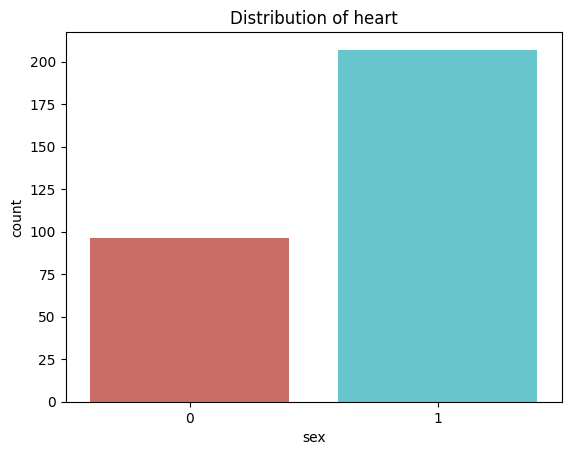

In [34]:
#countplot of sex (between males and females)
df_1 = df.copy()
sns.countplot(x = 'sex', data = df_1, palette = "hls")
plt.title("Distribution of heart");

These two groups are not equal represented. Males are more than females.

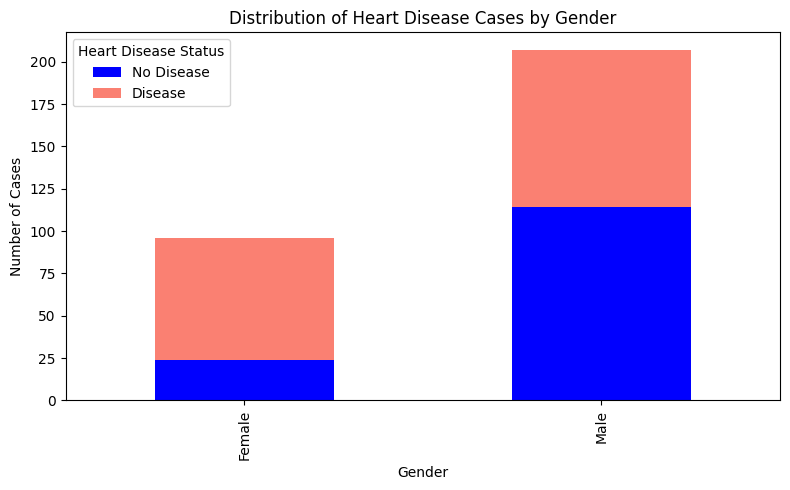

In [41]:
gender_df = df.groupby(['sex', 'target']).size().unstack()

# Rename index for clarity
gender_df.index = ['Female', 'Male']
gender_df.columns = ['No Disease', 'Disease']

# Plot
gender_df.plot(kind='bar', stacked=True, figsize=(8, 5), color=['blue', 'salmon'])
plt.title('Distribution of Heart Disease Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Cases')
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

We see more cases of disease in females and more no disease in males. This could be that the data collected among females showed more cases.

###**Resting Electrocardiogram Results**

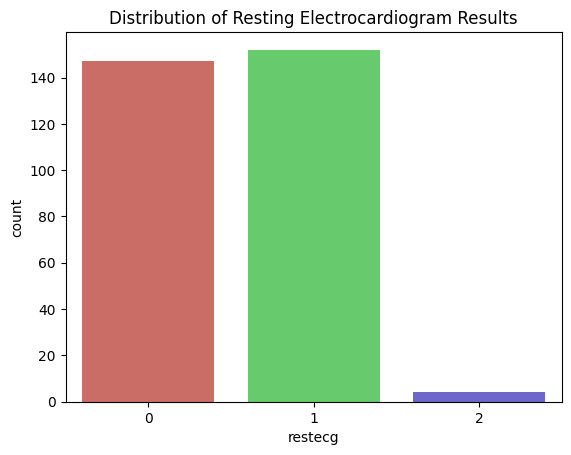

In [42]:
df_1 = df.copy()
sns.countplot(x = 'restecg', data = df_1, palette = "hls")
plt.title("Distribution of Resting Electrocardiogram Results");

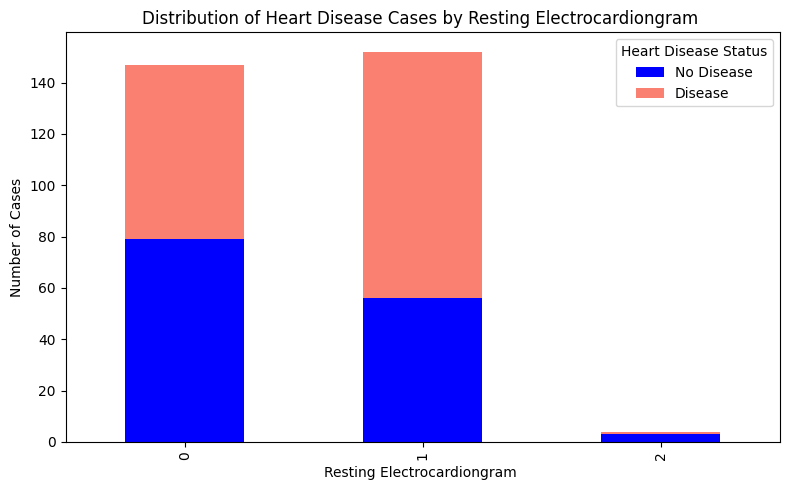

In [44]:
#countplot of Resting Electrocardiongram
Resting_cad_df = df.groupby(['restecg', 'target']).size().unstack()

# Rename index for clarity
Resting_cad_df.index = ['0','1', '2']
Resting_cad_df.columns = ['No Disease', 'Disease']

# Plot
Resting_cad_df.plot(kind='bar', stacked=True, figsize=(8, 5), color=['blue', 'salmon'])
plt.title('Distribution of Heart Disease Cases by Resting Electrocardiongram ')
plt.xlabel('Resting Electrocardiongram ')
plt.ylabel('Number of Cases')
plt.legend(title='Heart Disease Status')
plt.tight_layout()
plt.show()

Looks like no disease is on 2 and 0, but 1 has more cases of disease.

###**Age Distribution**

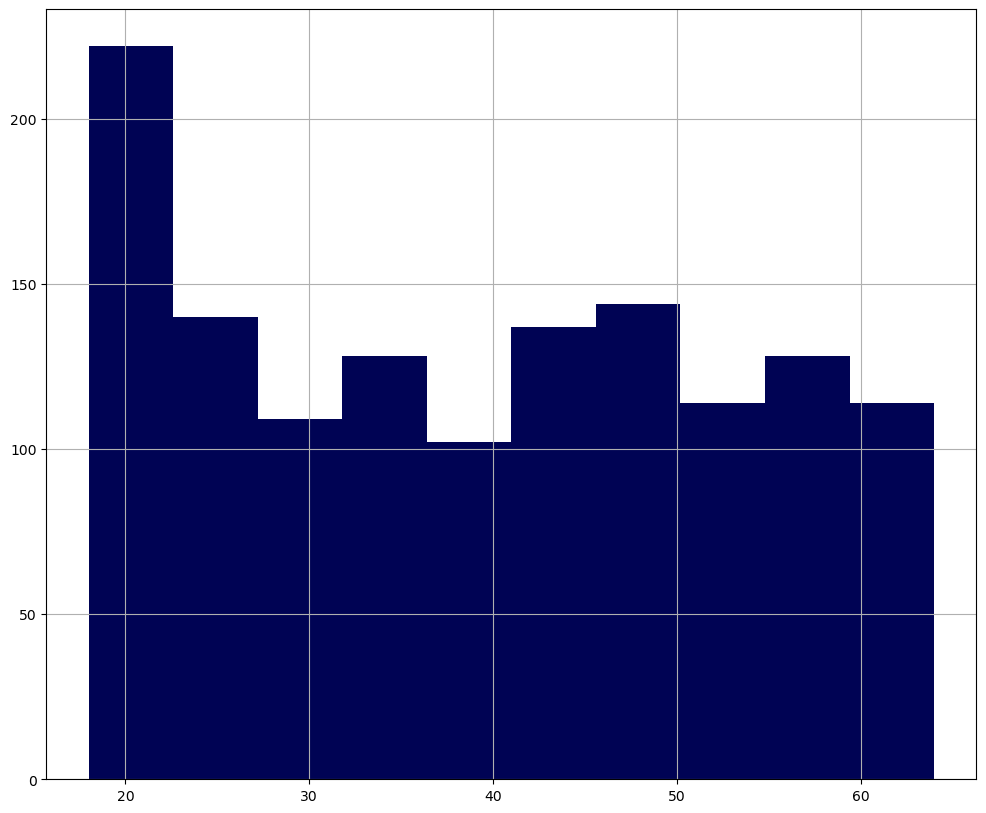

In [ ]:
df_1 = df.copy()
features = 'age'
df_1[features].hist(figsize = (12,10),  color = '#000354');

Most data points are of the age 20. The other age groups are fairly represented as well.

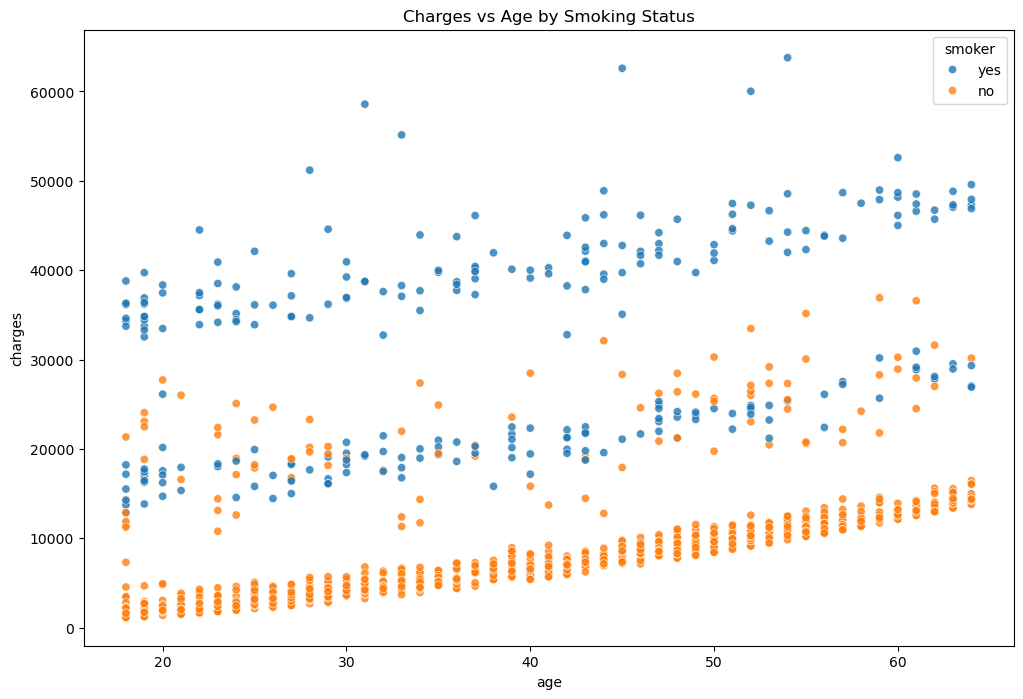

In [ ]:
#distribution of charges per age group, by smoking status
df_1 = df.copy()
plt.figure(figsize = (12,8))
sns.scatterplot(data = df_1, x = "age", y = "charges", hue = "smoker", alpha=0.8, sizes=(40,200))
plt.title("Charges vs Age by Smoking Status")
plt.show()

- There is a clear trend that irregardless of age, smokers end up paying more charges.
- Where charges are less than 10k - This comprises of non-smokers for all age groups.
- Whether charges are between 10k and 30k, both non-smokers and smokers are fairly represented and this is where we have average charges per age group.
- Where charges are greater than 30k - This group consists of virtually smokers.

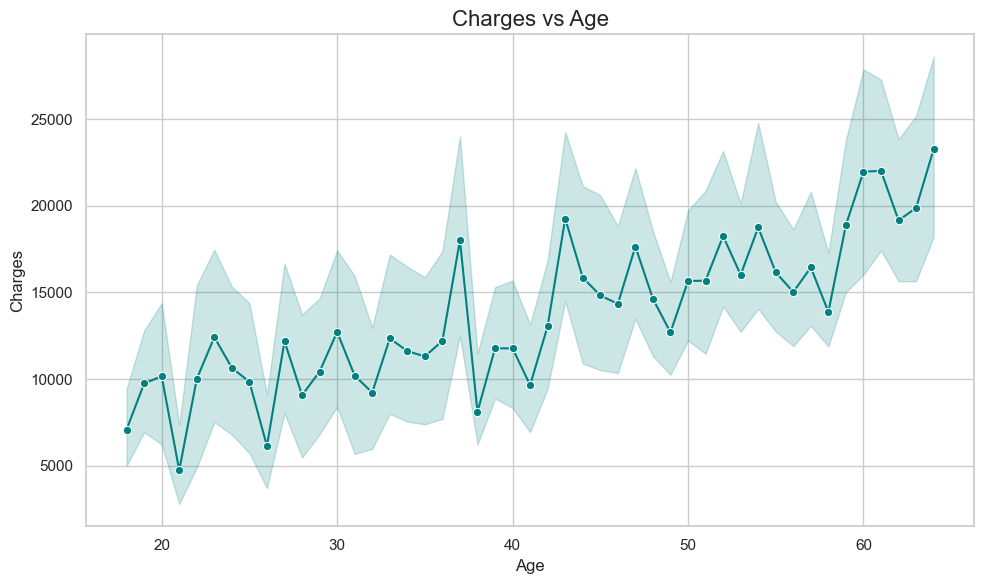

In [ ]:
# Create DataFrame
df_1 = df.copy()

# Set Seaborn style
sns.set(style="whitegrid")

# Create line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x = 'age', y = 'charges', data = df_1, marker='o', color='teal')

# Add labels and title
plt.title('Charges vs Age', fontsize=16)
plt.xlabel('Age', fontsize = 12)
plt.ylabel('Charges', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

Age definitely does have an impact in charges. As the age increases so do charges. Older people are charge a lot.

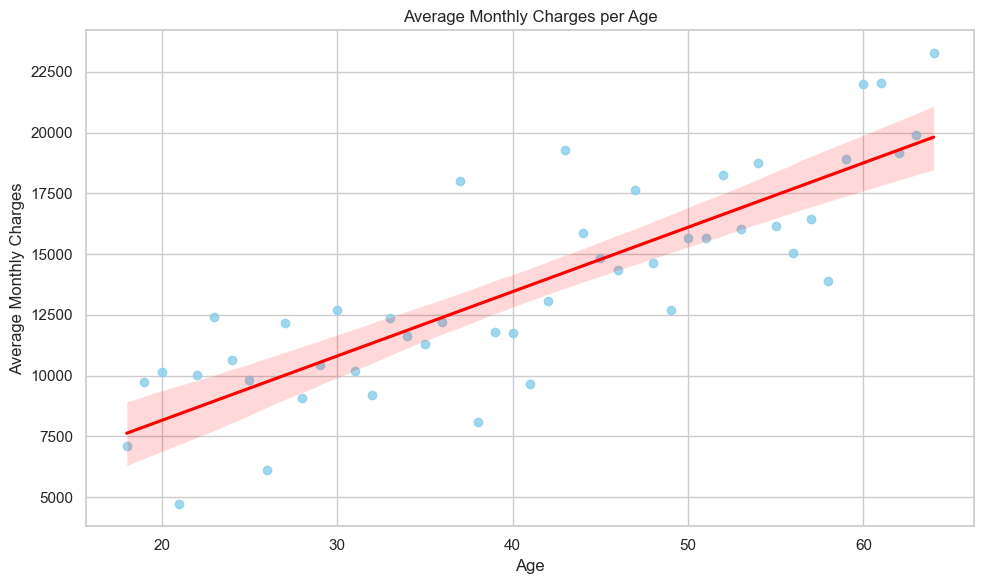

In [ ]:
# Average Monthly charges vs age
df_1 = df.copy()
df_temp = df_1.groupby('age')['charges'].mean().reset_index()
# Plot
plt.figure(figsize=(10, 6))
sns.regplot(data = df_temp, x = 'age', y = 'charges', scatter = True, color = 'skyblue', line_kws = {'color': 'red'})
plt.title('Average Monthly Charges per Age')
plt.xlabel('Age')
plt.ylabel('Average Monthly Charges')
plt.grid(True)
plt.tight_layout()
plt.show()

Trend is going up between charges and age. This shows a strong positive correlation between these two features.

# **Feature Selection and Engineering**


- This dataset does not have a lot of features(6). It is better to build the model first and see performance before dropping features.
- In terms of feature engineering, the categorical variables are converted to numerical variables using label encoding.



In [ ]:
# encoding categorical features
def Label_Encoder(df_1):
  columnsToEncode = list(df.select_dtypes(include=['category','object']))
  le = LabelEncoder()
  for feature in columnsToEncode:
    df[feature] = le.fit_transform(df[feature])
  return df

# final dataframe
df_1 = df.copy()
df_final = Label_Encoder(df_1)

In [ ]:
df_final.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# **Model Building and Testing**

In [ ]:
# splitting dataset into training and testing
df_data = df_final.copy()
X = df_data.drop(['charges'], axis = 1)
Y = df_data['charges']

# 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
# initialise model
model = LinearRegression()

#train model
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# **Model Evaluation**

In [ ]:
print(model.coef_)
print(model.score(x_test, y_test))

[ 2.57056264e+02 -1.87914567e+01  3.35781491e+02  4.25091456e+02
  2.36478181e+04 -2.71284266e+02]
0.7833463107364539


**Regression Evaluation Metrics**

In [ ]:
# Making Predictions
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

In [ ]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Root Mean Squared Error', 'R-squared'],
    'Training': [round(np.sqrt(mean_squared_error(y_train, y_train_pred)),4), round(model.score(x_train, y_train),4)],
    'Testing data': [round(np.sqrt(mean_squared_error(y_test, y_test_pred)),4),round(model.score(x_test, y_test),4)
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-------------------------+-----------+--------------+
|   |         Metric          | Training  | Testing data |
+---+-------------------------+-----------+--------------+
| 0 | Root Mean Squared Error | 6105.7893 |  5799.5871   |
| 1 |        R-squared        |  0.7417   |    0.7833    |
+---+-------------------------+-----------+--------------+


## **Scaling data to check if performance improves**

In [ ]:
df_2 = df_final.copy()


x = df_2.drop(['charges'], axis=1)
y = df_2['charges']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(x)

# 🧪 Train/Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

# initialise model
model_1 = LinearRegression()

#train model
model_1.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Making Predictions
y_pred_train = model_1.predict(X_train)
y_pred_test = model_1.predict(X_test)

In [ ]:
#Model evaluation
from sklearn.metrics import mean_squared_error

metrics = {
    'Metric': ['Root Mean Squared Error', 'R-squared'],
    'Training': [round(np.sqrt(mean_squared_error(Y_train, y_pred_train)),4), round(model.score(x_train, Y_train),4)],
    'Testing data': [round(np.sqrt(mean_squared_error(Y_test, y_pred_test)),4),round(model.score(x_test, Y_test),4)
    ]
}
# Create the DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df.reset_index(drop=True, inplace=True)

# Display the DataFrame
print(tabulate(metrics_df, headers = 'keys', tablefmt = 'pretty'))

+---+-------------------------+-----------+--------------+
|   |         Metric          | Training  | Testing data |
+---+-------------------------+-----------+--------------+
| 0 | Root Mean Squared Error | 6105.7893 |  5799.5871   |
| 1 |        R-squared        |  0.7417   |    0.7833    |
+---+-------------------------+-----------+--------------+


- We can see that the performance of our model stays the same. The model has a good training and Testing R-squared. It did not drop, but increase when using the testing data.